In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
cd /content/drive/MyDrive/t2dm/sheets

/content/drive/MyDrive/Colab Notebooks/t2dm/sheets


In [ ]:
import numpy as np
import pandas as pd

# **Data_Loading**

In [ ]:
workbook = pd.read_excel('Updated file_07112025.xlsx')
control_clamp = workbook.iloc[:68]
prediabetes_clamp = workbook.iloc[68:248]
print(control_clamp.shape)
print(prediabetes_clamp.shape)

(68, 18)
(180, 18)


In [ ]:
workbook1 = pd.read_excel("HG clamp complete data.xlsx", sheet_name=[0, 1, 2, 3, 4, 5])

control_col = workbook1[4]
prediabetes_col = workbook1[5]


control_col = control_col.drop([
       'BMI (kg/m2)', 'Age (yrs)', 'HbA1c %', 'Basal Glucose (mg/dl)',
       'Basal insulin (µU/ml)', 'Basal HOMA IR', 'Basal HOMA B %',
       'Basal C-peptide (ng/ml)', 'ISI (M/I) (mg/kg/min per µU/mL)',
       '1st phase insulin secretion (2-10min)', 'Disposition Index',
       '2nd phase insulin secretion (100-120min)',
       '1st phase C-peptide response (2-10min)',
       '2nd phase C-peptide response (100-120 min)',
       'Fasting C-peptide/fasting Insulin'], axis=1)
prediabetes_col = prediabetes_col.drop([
       'BMI (kg/m2)', 'Age (yrs)', 'HbA1c %', 'Basal Glucose (mg/dl)',
       'Basal insulin (µU/ml)', 'Basal HOMA IR', 'Basal HOMA B %',
       'Basal C-peptide (ng/ml)', 'ISI (M/I) (mg/kg/min per µU/mL)',
       '1st phase insulin secretion (2-10min)', 'Disposition Index',
       '2nd phase insulin secretion (100-120min)',
       '1st phase C-peptide response (2-10min)',
       '2nd phase C-peptide response (100-120 min)',
       'Fasting C-peptide/fasting Insulin'], axis=1)


control1 = pd.merge(control_clamp, control_col, on='Sample ID')

prediabetes1 = pd.merge(prediabetes_clamp, prediabetes_col, on='Sample ID')


In [ ]:
control1.columns = control1.columns.str.strip().str.replace(r'\s+', '_', regex=True)
prediabetes1.columns = prediabetes1.columns.str.strip().str.replace(r'\s+', '_', regex=True)
control1['Group'] = 'Control'
prediabetes1['Group'] = 'PD'
control1 = control1.loc[:, ~control1.columns.duplicated()]
prediabetes_df = prediabetes1.loc[:, ~prediabetes1.columns.duplicated()]
combined = pd.concat([control1, prediabetes1], axis=0)

In [ ]:
time = ['Basal', '2_min', '4_min', '6_min', '8_min', '10_min', '20_min', '30_min', '40_min', '50_min', '60_min', '70_min', '80_min', '90_min', '100_min', '110_min', '120_min']
time1 = ['2_min', '4_min', '6_min', '8_min', '10_min', '20_min', '30_min', '40_min', '50_min', '60_min', '70_min', '80_min', '90_min', '100_min', '110_min', '120_min']
var = ['_Glucose_(mg/dl)', '_Glucose_(mmol/l)', '_insulin_(µU/ml)', '_C-peptide_(ng/ml)']

# **HOMABlike**

In [ ]:
delta_glucose = combined[[f'{i}{var[1]}' for i in time]].sub(combined['Basal_Glucose_(mmol/l)'],axis=0)
delta_glucose.columns = [f'delta_{i}' for i in delta_glucose.columns]

delta_insulin = combined[[f'{i}{var[2]}' for i in time]].sub(combined['Basal_insulin_(µU/ml)'],axis=0)
delta_insulin.columns = [f'delta_{i}' for i in delta_insulin.columns]

homablike = (delta_insulin[[f'delta_{i}{var[2]}' for i in time]]).div(delta_glucose[[f'delta_{i}{var[1]}' for i in time]].to_numpy())
homablike.columns = [f'HOMABlike_{i}' for i in time]

In [ ]:
auc_1st_homablike = np.trapezoid(homablike[[f'HOMABlike_{i}' for i in time[:6]]].values, x = [0,2,4,6,8,10], axis=1)
auc_2nd_homablike = np.trapezoid(homablike[[f'HOMABlike_{i}' for i in time[5:]]].values, x = [10,20,30,40,50,60,70,80,90,100,110,120], axis=1)
auc_total_homablike = np.trapezoid(homablike[[f'HOMABlike_{i}' for i in time]].values, x = [0,2,4,6,8,10,20,30,40,50,60,70,80,90,100,110,120], axis=1)

combined['auc_1st_homablike'] = auc_1st_homablike
combined['auc_2nd_homablike'] = auc_2nd_homablike
combined['auc_total_homablike'] = auc_total_homablike

# **ISI_DIS_CLEste_Icre_auc**

In [ ]:
combined['glu_infu_100_120'] = combined[['100_min_Infusion_rate_(ml/min)','110_min_Infusion_rate_(ml/min)', '120_min_Infusion_rate_(ml/min)']].mean(axis=1)
combined['insulin_100_120'] = combined[['100_min_insulin_(µU/ml)', '110_min_insulin_(µU/ml)', '120_min_insulin_(µU/ml)']].mean(axis=1)
combined['ISI'] = (combined['glu_infu_100_120'] / combined['insulin_100_120']) * 100

In [ ]:
delta_insulin = combined[[f'{i}{var[2]}' for i in time]].sub(combined['Basal_insulin_(µU/ml)'],axis=0)
delta_insulin.columns = [f'delta_{i}' for i in delta_insulin.columns]

delta_c_pep = combined[[f'{i}{var[3]}' for i in time]].sub(combined['Basal_C-peptide_(ng/ml)'],axis=0)
delta_c_pep.columns = [f'delta_{i}' for i in delta_c_pep.columns]

In [ ]:
iauc_1st_insulin = np.trapezoid(delta_insulin[[f'delta_{i}{var[2]}' for i in time[:6]]].values, x = [0,2,4,6,8,10], axis=1)
iauc_2nd_insulin = np.trapezoid(delta_insulin[[f'delta_{i}{var[2]}' for i in time[5:]]].values, x = [10,20,30,40,50,60,70,80,90,100,110,120], axis=1)
iauc_steady_insulin = np.trapezoid(delta_insulin[[f'delta_{i}{var[2]}' for i in time[14:]]].values, x = [100,110,120], axis=1)
iauc_total_insulin = np.trapezoid(delta_insulin[[f'delta_{i}{var[2]}' for i in time]].values, x = [0,2,4,6,8,10,20,30,40,50,60,70,80,90,100,110,120], axis=1)

iauc_1st_c_pep = np.trapezoid(delta_c_pep[[f'delta_{i}{var[3]}' for i in time[:6]]].values, x = [0,2,4,6,8,10], axis=1)
iauc_2nd_c_pep = np.trapezoid(delta_c_pep[[f'delta_{i}{var[3]}' for i in time[5:]]].values, x = [10,20,30,40,50,60,70,80,90,100,110,120], axis=1)
iauc_steady_c_pep = np.trapezoid(delta_c_pep[[f'delta_{i}{var[3]}' for i in time[14:]]].values, x = [100,110,120], axis=1)
iauc_total_c_pep = np.trapezoid(delta_c_pep[[f'delta_{i}{var[3]}' for i in time]].values, x = [0,2,4,6,8,10,20,30,40,50,60,70,80,90,100,110,120], axis=1)

combined['iauc_insulin_0_10'] = iauc_1st_insulin
combined['iauc_insulin_10_120'] = iauc_2nd_insulin
combined['iauc_insulin_100_120'] = iauc_steady_insulin
combined['iauc_insulin_0_120'] = iauc_total_insulin

combined['iauc_c_pep_0_10'] = iauc_1st_c_pep
combined['iauc_c_pep_10_120'] = iauc_2nd_c_pep
combined['iauc_c_pep_100_120'] = iauc_steady_c_pep
combined['iauc_c_pep_0_120'] = iauc_total_c_pep

In [ ]:
combined ['Disposition'] = combined['ISI'] * combined['iauc_insulin_0_10']
combined['clearance_steady'] = combined['iauc_c_pep_100_120'] / combined['iauc_insulin_100_120']

# **AUC_SLP**

In [ ]:
auc_1st_insulin = np.trapezoid(combined[[f'{i}{var[2]}' for i in time[:6]]].values, x = [0,2,4,6,8,10], axis=1)
auc_2nd_insulin = np.trapezoid(combined[[f'{i}{var[2]}' for i in time[5:]]].values, x = [10,20,30,40,50,60,70,80,90,100,110,120], axis=1)
auc_total_insulin = np.trapezoid(combined[[f'{i}{var[2]}' for i in time]].values, x = [0,2,4,6,8,10,20,30,40,50,60,70,80,90,100,110,120], axis=1)


auc_1st_c_pep = np.trapezoid(combined[[f'{i}{var[3]}' for i in time[:6]]].values, x = [0,2,4,6,8,10], axis=1)
auc_2nd_c_pep = np.trapezoid(combined[[f'{i}{var[3]}' for i in time[5:]]].values, x = [10,20,30,40,50,60,70,80,90,100,110,120], axis=1)
auc_total_c_pep = np.trapezoid(combined[[f'{i}{var[3]}' for i in time]].values, x = [0,2,4,6,8,10,20,30,40,50,60,70,80,90,100,110,120], axis=1)



combined['auc_insulin_0_10'] = auc_1st_insulin
combined['auc_insulin_10_120'] = auc_2nd_insulin
combined['auc_insulin_0_120'] = auc_total_insulin

combined['auc_c_pep_0_10'] = auc_1st_c_pep
combined['auc_c_pep_10_120'] = auc_2nd_c_pep
combined['auc_c_pep_0_120'] = auc_total_c_pep

In [ ]:
from scipy.stats import linregress
slp_1st_insulin = combined[[f'{i}{var[2]}' for i in time[:6]]].apply(lambda x: linregress([0,2,4,6,8,10], x).slope, axis=1)
slp_0_6_insulin = combined[[f'{i}{var[2]}' for i in time[:4]]].apply(lambda x: linregress([0,2,4,6], x).slope, axis=1)
slp_6_10_insulin = combined[[f'{i}{var[2]}' for i in time[3:6]]].apply(lambda x: linregress([6,8,10], x).slope, axis=1)
slp_2nd_insulin = combined[[f'{i}{var[2]}' for i in time[5:]]].apply(lambda x: linregress([10,20,30,40,50,60,70,80,90,100,110,120], x).slope, axis=1)
slp_total_insulin = combined[[f'{i}{var[2]}' for i in time]].apply(lambda x: linregress([0,2,4,6,8,10,20,30,40,50,60,70,80,90,100,110,120], x).slope, axis=1)


slp_1st_c_pep = combined[[f'{i}{var[3]}' for i in time[:6]]].apply(lambda x: linregress([0,2,4,6,8,10], x).slope, axis=1)
slp_0_6_c_pep = combined[[f'{i}{var[3]}' for i in time[:4]]].apply(lambda x: linregress([0,2,4,6], x).slope, axis=1)
slp_6_10_c_pep = combined[[f'{i}{var[3]}' for i in time[3:6]]].apply(lambda x: linregress([6,8,10], x).slope, axis=1)
slp_2nd_c_pep = combined[[f'{i}{var[3]}' for i in time[5:]]].apply(lambda x: linregress([10,20,30,40,50,60,70,80,90,100,110,120], x).slope, axis=1)
slp_total_c_pep = combined[[f'{i}{var[3]}' for i in time]].apply(lambda x: linregress([0,2,4,6,8,10,20,30,40,50,60,70,80,90,100,110,120], x).slope, axis=1)



combined['slp_insulin_0_10'] = slp_1st_insulin
combined['slp_insulin_0_6'] = slp_0_6_insulin
combined['slp_insulin_6_10'] = slp_6_10_insulin
combined['slp_insulin_10_120'] = slp_2nd_insulin
combined['slp_insulin_0_120'] = slp_total_insulin

combined['slp_c_pep_0_10'] = slp_1st_c_pep
combined['slp_c_pep_0_6'] = slp_0_6_c_pep
combined['slp_c_pep_6_10'] = slp_6_10_c_pep
combined['slp_c_pep_10_120'] = slp_2nd_c_pep
combined['slp_c_pep_0_120'] = slp_total_c_pep

# **Basal_Indices**

In [ ]:
combined['Basal_homa_c'] = (combined['Basal_Glucose_(mmol/l)'] * combined['Basal_C-peptide_(ng/ml)'])/22.5
combined['Basal_homabeta_c'] = (20 * combined['Basal_C-peptide_(ng/ml)']) / (combined['Basal_Glucose_(mmol/l)']-3.5)
combined['Basal_cpi'] = combined['Basal_C-peptide_(ng/ml)'] * 0.333 / combined['Basal_Glucose_(mmol/l)']
combined['Basal_c_glu'] = 20 / (combined['Basal_C-peptide_(ng/ml)'] * combined['Basal_Glucose_(mg/dl)'])
combined['Basal_quicki'] = 1 / (np.log10(combined['Basal_insulin_(µU/ml)']) * np.log10(combined['Basal_Glucose_(mg/dl)']))

In [ ]:
combined['Beta_CIndex'] = combined['Basal_C-peptide_(ng/ml)']/combined['Basal_Glucose_(mmol/l)']
combined['Beta_IIndex'] = combined['Basal_insulin_(µU/ml)']/combined['Basal_Glucose_(mmol/l)']
combined['hept_index'] = np.log10((combined['Basal_C-peptide_(ng/ml)'] * 331)/(combined['Basal_insulin_(µU/ml)'] * 6.945))
combined['cpepauc0_120/insulinauc0_120'] = combined['auc_c_pep_0_120']/combined['auc_insulin_0_120']

# **ISR**

In [ ]:
combined.shape

(248, 181)

In [ ]:
# Kinetic parameters (min^-1)
k01 = 0.066
k12 = 0.056
k21 = 0.063

# Central compartment volume (L)
V1 = 4.5

In [ ]:
#C-peptide impulse response function

def cpep_impulse(t, k01, k12, k21, V1):
    alpha = 0.5 * ((k01 + k12 + k21) +
                   np.sqrt((k01 + k12 + k21)**2 - 4*k01*k21))
    beta  = 0.5 * ((k01 + k12 + k21) -
                   np.sqrt((k01 + k12 + k21)**2 - 4*k01*k21))

    return (np.exp(-beta*t) - np.exp(-alpha*t)) / (V1 * (alpha - beta))



#Build convolution matrix

def build_convolution_matrix(time):
    n = len(time)
    H = np.zeros((n, n))
    for i in range(n):
        for j in range(i + 1):
            dt = time[i] - time[j]
            if dt >= 0:
                H[i, j] = cpep_impulse(dt, k01, k12, k21, V1)
    return H



#Deconvolution to estimate ISR

from numpy.linalg import solve

def estimate_ISR(time, cpep, lam=0.1):
    H = build_convolution_matrix(time)

    # Second-derivative regularization matrix
    n = len(time)
    D = np.zeros((n-2, n))
    for i in range(n-2):
        D[i, i:i+3] = [1, -2, 1]

    # Solve regularized least squares
    A = H.T @ H + lam * (D.T @ D)
    b = H.T @ cpep

    ISR = solve(A, b)
    return ISR

In [ ]:
df_cpep = combined[[f'{i}{var[3]}' for i in time]]
df_cpep.head()

,Basal_C-peptide_(ng/ml),2_min_C-peptide_(ng/ml),4_min_C-peptide_(ng/ml),6_min_C-peptide_(ng/ml),8_min_C-peptide_(ng/ml),10_min_C-peptide_(ng/ml),20_min_C-peptide_(ng/ml),30_min_C-peptide_(ng/ml),40_min_C-peptide_(ng/ml),50_min_C-peptide_(ng/ml),60_min_C-peptide_(ng/ml),70_min_C-peptide_(ng/ml),80_min_C-peptide_(ng/ml),90_min_C-peptide_(ng/ml),100_min_C-peptide_(ng/ml),110_min_C-peptide_(ng/ml),120_min_C-peptide_(ng/ml)
0,1.43,1.31,4.77,4.24,4.01,3.95,3.98,4.36,5.48,6.02,6.57,7.16,7.76,8.15,8.56,9.46,8.78
1,1.23,1.69,4.34,4.53,3.65,4.13,6.16,7.65,6.77,8.34,11.60,13.50,14.30,16.70,19.50,22.00,19.90
2,1.92,2.75,4.66,5.50,5.74,6.07,5.92,6.89,7.28,10.40,11.30,10.40,14.10,14.90,15.00,17.50,18.40
3,2.29,2.47,7.26,8.15,7.73,7.97,9.88,8.62,10.20,12.30,13.10,15.30,23.50,25.20,21.10,19.40,24.30
4,1.76,3.83,5.02,5.50,NaN,6.85,8.18,8.91,10.70,12.80,15.20,13.60,15.40,13.00,16.50,11.60,18.40


In [ ]:
t = np.array([0,2,4,6,8,10,20,30,40,50,60,70,80,90,100,110,120])
isr_list = []
for i in range(len(df_cpep)):
    cpep = df_cpep.iloc[i].values
    isr_nmol_l_min = estimate_ISR(t, cpep)
    isr_pmol_min = isr_nmol_l_min * 1000
    isr_list.append(isr_pmol_min)


isr_df = pd.DataFrame(isr_list, columns=df_cpep.columns)

In [ ]:
isr_df['Sample_ID'] = combined['Sample_ID'].values
isr_df.to_excel('/content/drive/MyDrive/t2dm/results/ISR_withna.xlsx')

In [ ]:
isr_df = isr_df.dropna()

isr_df['first_phase_ISR'] = isr_df[[f'{i}{var[3]}' for i in time[:6]]].mean(axis=1)

isr_df['second_phase_ISR_10_120'] = isr_df[[f'{i}{var[3]}' for i in time[5:]]].mean(axis=1)

isr_df['second_phase_ISR_60_120'] = isr_df[[f'{i}{var[3]}' for i in time[10:]]].mean(axis=1)

In [ ]:
isr_df.to_excel('/content/drive/MyDrive/t2dm/results/ISR.xlsx')

# **File_Exp**

In [ ]:
columns_import = ['Sample_ID', 'glu_infu_100_120', 'insulin_100_120', 'ISI', 'Disposition', 'clearance_steady', 'iauc_insulin_0_10', 'iauc_insulin_10_120', 'iauc_insulin_100_120', 'iauc_insulin_0_120',
                  'iauc_c_pep_0_10', 'iauc_c_pep_10_120', 'iauc_c_pep_100_120', 'iauc_c_pep_0_120', 'auc_insulin_0_10', 'auc_insulin_10_120', 'auc_insulin_0_120', 'auc_c_pep_0_10',
                  'auc_c_pep_10_120', 'auc_c_pep_0_120', 'slp_insulin_0_10', 'slp_insulin_0_6', 'slp_insulin_6_10', 'slp_insulin_10_120', 'slp_insulin_0_120',
                  'slp_c_pep_0_10', 'slp_c_pep_0_6', 'slp_c_pep_6_10', 'slp_c_pep_10_120', 'slp_c_pep_0_120', 'Basal_homa_c', 'Basal_homabeta_c', 'Basal_cpi', 'Basal_c_glu', 'Basal_quicki']
df_control = combined[combined['Group'] == 'Control'][columns_import]
df_prediabetes = combined[combined['Group'] == 'PD'][columns_import]
df_control.shape
#df_prediabetes.shape

(68, 35)

In [ ]:
df1 = pd.merge(workbook1[4], df_control, left_on='Sample ID', right_on='Sample_ID')
df2 = pd.merge(workbook1[5], df_prediabetes, left_on='Sample ID', right_on='Sample_ID')

In [ ]:
with pd.ExcelWriter("/content/drive/MyDrive/t2dm/results/combined.xlsx", engine="openpyxl") as writer:
    df1.to_excel(writer, sheet_name="Control", index=False)
    df2.to_excel(writer, sheet_name="Prediabetes", index=False)

# **Scale_Outlier**

In [ ]:
workbook2 = pd.read_excel("AIG Final Data.xlsx", sheet_name=None)

control2 = workbook2['Control']
prediabetes2 = workbook2['Prediabetes']

In [ ]:
dict.keys(workbook2)

dict_keys(['Control', 'Prediabetes', 'Demographics & lab parameters', 'Imaging data'])

In [ ]:
control2.columns = control2.columns.str.strip().str.replace(r'\s+', '_', regex=True)
prediabetes2.columns = prediabetes2.columns.str.strip().str.replace(r'\s+', '_', regex=True)
control2['Group'] = 'Control'
prediabetes2['Group'] = 'PD'

combined2 = pd.concat([control2, prediabetes2], axis=0)

/tmp/ipykernel_299/2114233339.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  control2['Group'] = 'Control'
/tmp/ipykernel_299/2114233339.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prediabetes2['Group'] = 'PD'


In [ ]:
from scipy.stats import median_abs_deviation
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from scipy.stats import mannwhitneyu
from scipy.spatial import ConvexHull
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
combined2.columns.to_list()

['Sample_ID', 'Basal_HOMA_B_%', 'Basal_C-peptide_(ng/dl)', 'Group']

In [ ]:
cols_con = ['Basal_HOMA_B_%', 'Basal_C-peptide_(ng/dl)']
cols_com = ['HOMA_B', 'Basal_C-peptide']

In [ ]:
combined2 = combined2.dropna(subset=cols_con)

In [ ]:
#cols_con = ['Basal_Glucose', 'auc_C_pep_0_120']

med_com = combined2[cols_con].median()

mad_com = median_abs_deviation(combined2[cols_con], scale = 'normal')
print(mad_com)

k_com = 5
threshold_com = k_com * mad_com

bool_com = np.abs(combined2[cols_con] - med_com) <= threshold_com
#print(bool_com)

out_rmvd = combined2[bool_com.all(axis=1)]
outliers_com = combined2[~bool_com.all(axis=1)]
#print(clean_data_com)
#print(outliers_com)

[ 46.80397186 600.45389849]


In [ ]:
abs_median = abs(out_rmvd[cols_con] - out_rmvd[cols_con].median())
#print(abs_median)
mad = abs_median.median()
#print(mad)
a = 0.6745 * ((out_rmvd[cols_con] - out_rmvd[cols_con].median()) / mad)
a [cols_com] = a [cols_con]
a = a.drop(cols_con, axis=1)

clean_df = pd.concat([out_rmvd, a], axis=1)
print(clean_df.columns)

Index(['Sample_ID', 'Basal_HOMA_B_%', 'Basal_C-peptide_(ng/dl)', 'Group',
       'HOMA_B', 'Basal_C-peptide'],
      dtype='object')


In [ ]:
df_control = clean_df[clean_df['Group'] == 'Control']
filtered_df_scaled = clean_df[clean_df['Group'] == 'PD']
print(df_control.shape)
print(filtered_df_scaled.shape)

(63, 6)
(175, 6)


# **K_Means**

[0 1 1 0 1 1 0 1 1 1 0 1 1 0 0 0 1 0 0 1 0 0 0 1 1 1 1 0 1 0 1 0 1 1 0 0 0
 0 1 1 1 1 1 0 0 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 0 1 0 1 1 0 1
 1 1 0 1 1 1 0 1 0 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 0 0 1 1 1 1 1 0 1 1
 1 0 1 1 1 1 1 1 1 0 1 0 1 0 1 1 1 1 1 1 1 0 1 0 1 1 1]
[0 1 2 2 2 1 0 1 2 1 0 1 2 2 0 0 1 0 2 1 0 2 2 1 1 1 2 0 2 2 2 2 1 1 2 2 2
 2 2 2 2 1 1 2 2 2 2 1 1 1 1 2 1 1 1 0 2 1 2 1 1 2 1 1 1 1 1 1 1 2 2 1 1 1
 2 1 1 1 1 1 1 1 2 1 1 1 1 2 1 1 1 1 2 1 1 2 2 2 0 1 1 2 1 2 2 2 2 1 2 2 1
 1 1 2 1 1 2 2 2 0 1 1 1 2 2 2 2 1 1 1 0 1 1 1 2 1 1 1 0 2 1 1 1 2 1 0 1 1
 2 2 1 1 2 1 1 1 1 2 2 0 2 0 1 1 1 1 1 1 1 2 1 0 1 1 1]
{2: np.float64(0.5108771901635469), 3: np.float64(0.3696305849010561)}


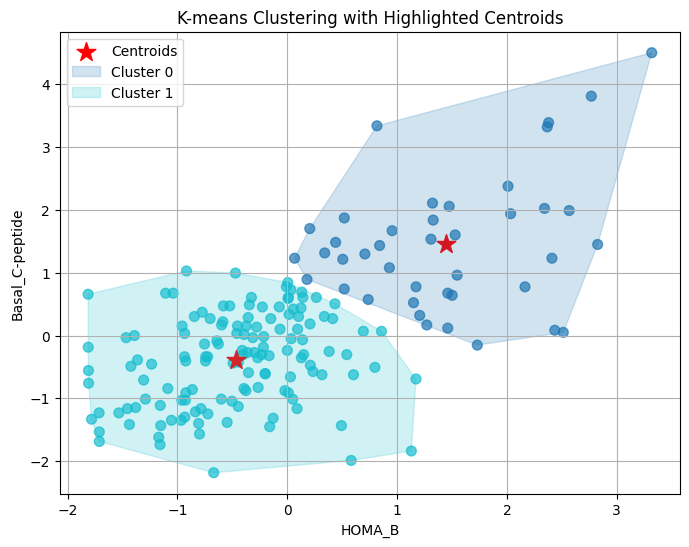

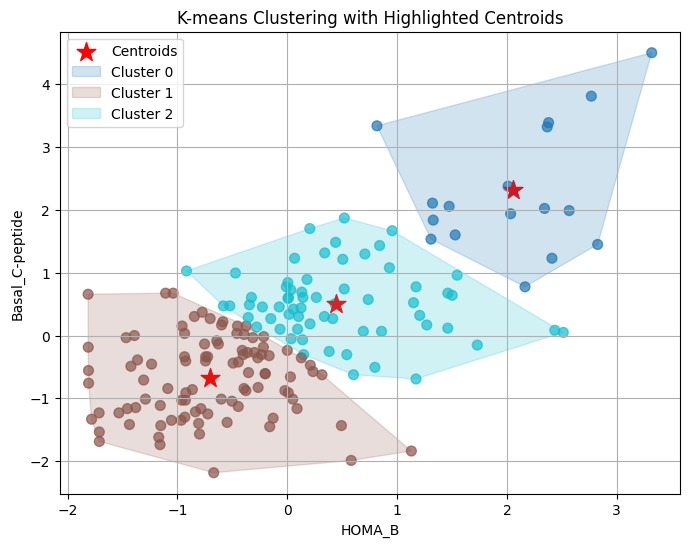

In [ ]:
clust_pre = filtered_df_scaled[['Sample_ID', cols_com[0], cols_com[1]]]

sample_ids = clust_pre['Sample_ID']

filtered_df = filtered_df_scaled[cols_com]
filtered_df = filtered_df[cols_com].to_numpy()
#print(filtered_df.head())


#control_points = df_control[['HOMA B', 'Auc_c_pep_0_10']].to_numpy()
#control_mean = control_points.mean(axis=0)


k = [2, 3]
cluster_results = {}
silhouette_scores = {}

for i in k:
  kmeans = KMeans(n_clusters=i, max_iter=100000)
  cluster_labels = kmeans.fit_predict(filtered_df)
  print(cluster_labels)
  centroids = kmeans.cluster_centers_
  score = silhouette_score(filtered_df, cluster_labels)
  cluster_results[i] = clust_pre.copy()
  cluster_results[i]['Cluster'] = cluster_labels
  silhouette_scores[i] = score
  plt.figure(figsize=(8, 6))
  cmap = plt.get_cmap('tab10')
  plt.scatter(filtered_df[:, 0], filtered_df[:, 1], c=cluster_labels, cmap=cmap, s=50, alpha=0.7)
  plt.scatter(centroids[:, 0], centroids[:, 1], c='red', s=200, marker='*', label='Centroids')

  #plt.scatter(control_points[:, 0], control_points[:, 1], color='black', marker='x', s=60, label='Controls')
  #plt.scatter(control_mean[0], control_mean[1], color='black', marker='D', s=60, label='Control Mean')


  for cluster in np.unique(cluster_labels):
      cluster_points = filtered_df[cluster_labels == cluster]
      if len(cluster_points) >= 3:
          hull = ConvexHull(cluster_points)
          vertices = cluster_points[hull.vertices]
          vertices = np.vstack((vertices, vertices[0]))
          color = cmap(cluster / (len(np.unique(cluster_labels)) - 1) if len(np.unique(cluster_labels)) > 1 else 0)
          plt.fill(vertices[:, 0], vertices[:, 1], color=color, alpha=0.2,
                    label=f'Cluster {cluster}')

  plt.title('K-means Clustering with Highlighted Centroids')
  plt.xlabel(cols_com[0])
  plt.ylabel(cols_com[1])
  plt.legend()
  plt.grid(True)
  plt.savefig(f'/content/drive/MyDrive/t2dm/results/k_means_{i}_Median+MAD_ch.png', dpi=300, bbox_inches='tight')
print(silhouette_scores)
cluster_results[2].to_csv('/content/drive/MyDrive/t2dm/results/cluster_results_2_Median+MAD_ch.csv', index=False)
cluster_results[3].to_csv('/content/drive/MyDrive/t2dm/results/cluster_results_3_Median+MAD_ch.csv', index=False)

In [ ]:
cluster_result_df = pd.merge(combined2, cluster_results[2][['Sample_ID','Cluster']], on='Sample_ID')
#print(cluster_result_df)

In [ ]:
df_cluster_0 = cluster_result_df[cluster_result_df['Cluster'] == 0]
df_cluster_1 = cluster_result_df[cluster_result_df['Cluster'] == 1]
#df_cluster_2 = cluster_result_df[cluster_result_df['Cluster'] == 2]
print(df_cluster_0.shape)
print(df_cluster_1.shape)
#print(df_cluster_2.shape)

(41, 5)
(134, 5)


In [ ]:
df_control['Cluster'] = 'Control'
df_control.shape

/tmp/ipython-input-996845851.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_control['Cluster'] = 'Control'


(62, 243)

In [ ]:
combined_clus = pd.concat([df_control, cluster_result_df], axis=0)
combined_clus['Cluster'] = combined_clus['Cluster'].replace({0: 'PD1', 1: 'PD2'})

# **PCA_K_Means**

/tmp/ipython-input-1716882098.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  clust_pre['PCA1'] = X_pca[:, 0]
/tmp/ipython-input-1716882098.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  clust_pre['PCA2'] = X_pca[:, 1]


Hopkins statistic: 0.3296
[1 0 1 0 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 0 0 1 0 1 0 1 1 1 1 1 0 1
 1 1 0 1 1 1 1 0 1 1 1 0 1 0 1 1 1 0 0 0 1 1 0 1 0 0 0 0 1 1 1 0 0 1 0 1 1
 1 0 0 0 1 1 1 0 1 0 1 1 0 0 0 1 0 0 0 0 1 0 0 1 1 0 1 0 0 0 1 1 1 1 1 1 1
 1 1 0 0 0 0 0 1 1 1 1 0 0 1 1 1 1 0 0 0 1 0 0 0 1 0 0 0 1 0 0 0 0 1 1 1 1
 1 1 1 0 0 0 0 0 1 0 1 1 1 1 1 1 0 1 0 1 0 1 1 0 1 1 1 1]
[1 2 1 2 1 1 1 1 0 0 1 1 1 1 1 1 1 1 1 1 1 2 1 1 2 2 1 0 0 0 1 0 1 1 1 2 0
 1 1 2 1 1 1 1 2 1 1 1 2 1 2 1 1 1 0 2 0 0 1 2 1 2 2 0 0 1 1 1 2 2 1 2 0 1
 0 2 0 0 1 1 1 2 1 2 1 1 2 0 0 1 2 0 0 2 1 2 2 1 0 2 0 2 2 2 1 1 0 0 1 1 1
 1 0 2 2 0 2 2 1 0 1 0 2 2 1 1 0 1 2 2 2 1 2 2 2 1 2 2 2 1 0 2 2 2 1 0 1 1
 1 0 0 2 2 2 2 2 1 0 1 1 0 1 1 1 2 0 2 1 2 0 0 2 0 0 0 1]
{2: np.float64(0.47124175037982297), 3: np.float64(0.3596584702329018)}


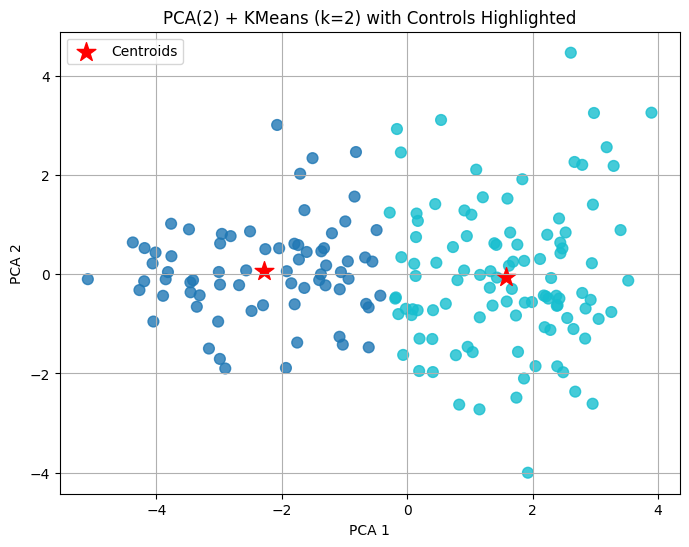

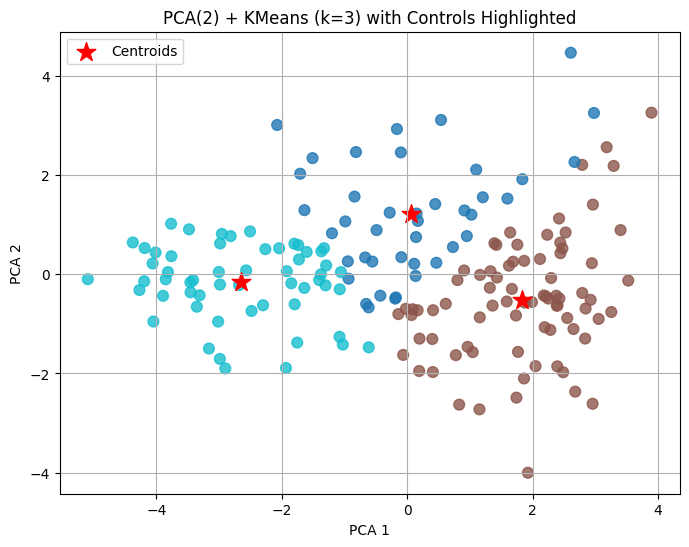

In [ ]:
from sklearn.decomposition import PCA

clust_pre = filtered_df_scaled[['Sample_ID', cols_con[0], cols_con[1], cols_con[3], cols_con[4]]]

sample_ids = clust_pre['Sample_ID']

filtered_df = filtered_df_scaled[cols_con]
filtered_df = filtered_df[cols_con].to_numpy()


pca = PCA(n_components=2)
X_pca = pca.fit_transform(filtered_df)

clust_pre['PCA1'] = X_pca[:, 0]
clust_pre['PCA2'] = X_pca[:, 1]


from pyclustertend import hopkins
hopkins_stat = hopkins(filtered_df, 40)
print(f"Hopkins statistic: {hopkins_stat:.4f}")


k = [2, 3]
cluster_results = {}
silhouette_scores = {}

for i in k:
  kmeans = KMeans(n_clusters=i, max_iter=500)
  cluster_labels = kmeans.fit_predict(X_pca)
  print(cluster_labels)
  centroids = kmeans.cluster_centers_
  score = silhouette_score(X_pca, cluster_labels)
  cluster_results[i] = clust_pre.copy()
  cluster_results[i]['Cluster'] = cluster_labels
  silhouette_scores[i] = score


  plt.figure(figsize=(8,6))
  cmap = plt.get_cmap('tab10')


  #patients = cluster_results[i][cluster_results[i]['Group'] == 'PD']
  plt.scatter(cluster_results[i]['PCA1'], cluster_results[i]['PCA2'], c=cluster_labels, cmap=cmap, s=60, alpha=0.8)


  #controls = cluster_results[i][cluster_results[i]['Group'] == 'Control']
  #plt.scatter(controls['PCA1'], controls['PCA2'], marker='x', s=80, c='black', label='Controls')

  plt.scatter(centroids[:, 0], centroids[:, 1], c='red', marker='*', s=200, label='Centroids')

  plt.xlabel("PCA 1")
  plt.ylabel("PCA 2")
  plt.title(f"PCA(2) + KMeans (k={i}) with Controls Highlighted")
  plt.legend()
  plt.grid(True)

  plt.savefig(f'/content/drive/MyDrive/Colab Notebooks/t2dm/combined/updated/trial/k_means_{i}_Median+MAD.png', dpi=300)


print(silhouette_scores)
cluster_results[2].to_csv('/content/drive/MyDrive/t2dm/results/cluster_results_2_Median+MAD.csv', index=False)
cluster_results[3].to_csv('/content/drive/MyDrive/t2dm/results/cluster_results_3_Median+MAD.csv', index=False)

In [ ]:
cluster_result_df = pd.merge(combined, cluster_results[2][['Sample_ID','Cluster']], on='Sample_ID')
#print(cluster_result_df)

In [ ]:
df_cluster_0 = cluster_result_df[cluster_result_df['Cluster'] == 0]
df_cluster_1 = cluster_result_df[cluster_result_df['Cluster'] == 1]
#df_cluster_2 = cluster_result_df[cluster_result_df['Cluster'] == 2]
print(df_cluster_0.shape)
print(df_cluster_1.shape)
#print(df_cluster_2.shape)

(72, 242)
(104, 242)
